In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

In [2]:
df = pd.read_csv("loan_dataset.csv")


In [3]:
df.head()
df.info()
df.isnull().sum()
# df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 20 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Applicant_ID        950 non-null    float64
 1   Applicant_Income    950 non-null    float64
 2   Coapplicant_Income  950 non-null    float64
 3   Employment_Status   950 non-null    object 
 4   Age                 950 non-null    float64
 5   Marital_Status      950 non-null    object 
 6   Dependents          950 non-null    float64
 7   Credit_Score        950 non-null    float64
 8   Existing_Loans      950 non-null    float64
 9   DTI_Ratio           950 non-null    float64
 10  Savings             950 non-null    float64
 11  Collateral_Value    950 non-null    float64
 12  Loan_Amount         950 non-null    float64
 13  Loan_Term           950 non-null    float64
 14  Loan_Purpose        950 non-null    object 
 15  Property_Area       950 non-null    object 
 16  Educati

Applicant_ID          50
Applicant_Income      50
Coapplicant_Income    50
Employment_Status     50
Age                   50
Marital_Status        50
Dependents            50
Credit_Score          50
Existing_Loans        50
DTI_Ratio             50
Savings               50
Collateral_Value      50
Loan_Amount           50
Loan_Term             50
Loan_Purpose          50
Property_Area         50
Education_Level       50
Gender                50
Employer_Category     50
Loan_Approved         50
dtype: int64

# Handling Missing Value


In [4]:
categorical_cols = df.select_dtypes(include=["object"]).columns
numerical_cols = df.select_dtypes(include=["float64"]).columns

In [5]:
from sklearn.impute import SimpleImputer

num_imp = SimpleImputer(strategy = 'mean')
df[numerical_cols] = num_imp.fit_transform(df[numerical_cols])

In [6]:
df[numerical_cols].head()

,Applicant_ID,Applicant_Income,Coapplicant_Income,Age,Dependents,Credit_Score,Existing_Loans,DTI_Ratio,Savings,Collateral_Value,Loan_Amount,Loan_Term
0,1.0,17795.0,1387.0,51.0,0.0,637.0,4.0,0.53,19403.0,45638.0,16619.0,84.0
1,2.0,2860.0,2679.0,46.0,3.0,621.0,2.0,0.30,2580.0,49272.0,38687.0,48.0
2,3.0,7390.0,2106.0,25.0,2.0,674.0,4.0,0.20,13844.0,6908.0,27943.0,72.0
3,4.0,13964.0,8173.0,40.0,2.0,579.0,3.0,0.31,9553.0,10844.0,27819.0,60.0
4,5.0,13284.0,4223.0,31.0,2.0,721.0,1.0,0.29,9386.0,37629.0,12741.0,72.0


In [7]:
cat_imp = SimpleImputer(strategy = 'most_frequent')
df[categorical_cols] = cat_imp.fit_transform(df[categorical_cols])

In [8]:
df.head()
df.isnull().sum()

Applicant_ID          0
Applicant_Income      0
Coapplicant_Income    0
Employment_Status     0
Age                   0
Marital_Status        0
Dependents            0
Credit_Score          0
Existing_Loans        0
DTI_Ratio             0
Savings               0
Collateral_Value      0
Loan_Amount           0
Loan_Term             0
Loan_Purpose          0
Property_Area         0
Education_Level       0
Gender                0
Employer_Category     0
Loan_Approved         0
dtype: int64

# EDA :- Exploratory Data Analysis

Text(0.5, 1.0, 'IS Loan approved or not')

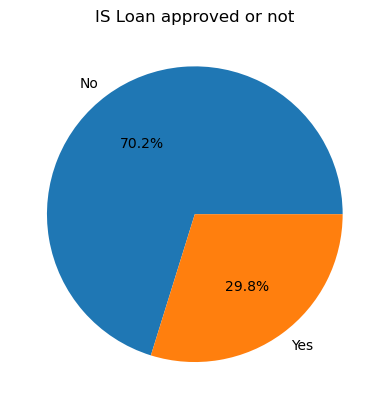

In [9]:

# How balanced our  classes are?

classes_count = df["Loan_Approved"].value_counts()
plt.pie(classes_count, labels=["No","Yes"],autopct= "%1.1f%%")
plt.title("IS Loan approved or not")

[Text(0, 0, '621'), Text(0, 0, '379')]

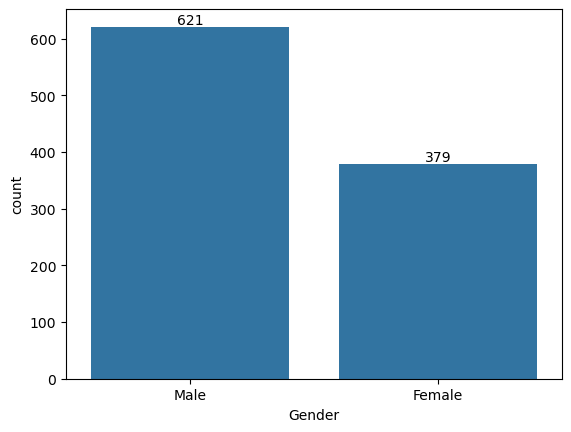

In [10]:
 # analyze categories

gender_cnt = df["Gender"].value_counts()
ax = sns.barplot(gender_cnt)
ax.bar_label(ax.containers[0])

# edu_cnt = df["Education_Level"].value_counts()
# ax = sns.barplot(edu_cnt)
# ax.bar_label(ax.containers[0])

<Axes: xlabel='Applicant_Income', ylabel='Count'>

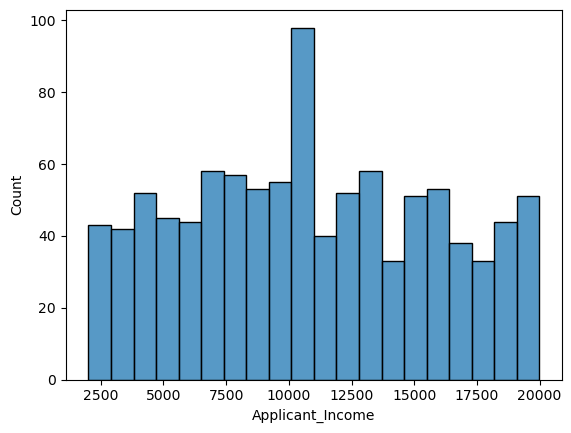

In [11]:
# analyze income

sns.histplot(
    data = df,
    x = "Applicant_Income",
    bins = 20
)

<Axes: xlabel='Coapplicant_Income', ylabel='Count'>

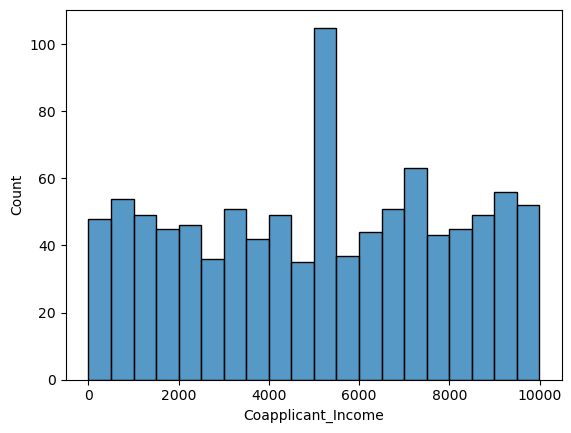

In [12]:
sns.histplot(
    data = df,
    x = "Coapplicant_Income",
    bins = 20
)

<Axes: xlabel='Loan_Approved', ylabel='Applicant_Income'>

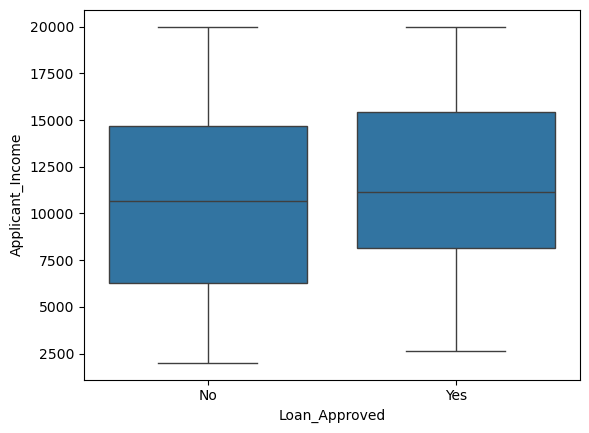

In [13]:
# Outliers box plot

sns.boxplot(
    data = df,
    x = "Loan_Approved",
    y = "Applicant_Income"
)

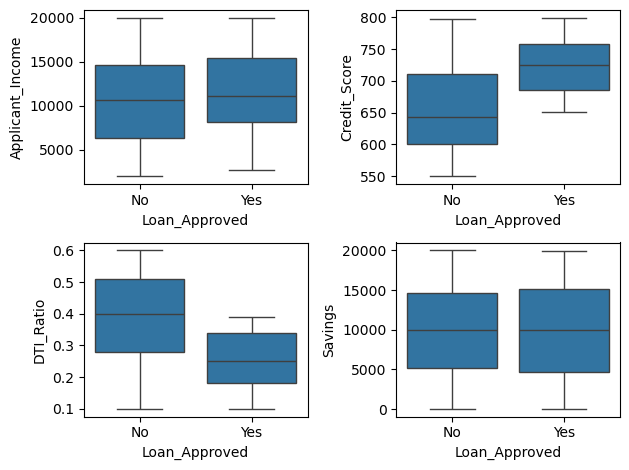

In [14]:
fig, axes = plt.subplots(2,2)
sns.boxplot(ax = axes[0,0], data = df,x = "Loan_Approved",y = "Applicant_Income")
sns.boxplot(ax = axes[0,1], data = df,x = "Loan_Approved",y = "Credit_Score")
sns.boxplot(ax = axes[1,0], data = df,x = "Loan_Approved",y = "DTI_Ratio")
sns.boxplot(ax = axes[1,1], data = df,x = "Loan_Approved",y = "Savings")

plt.tight_layout()

<Axes: xlabel='Credit_Score', ylabel='Count'>

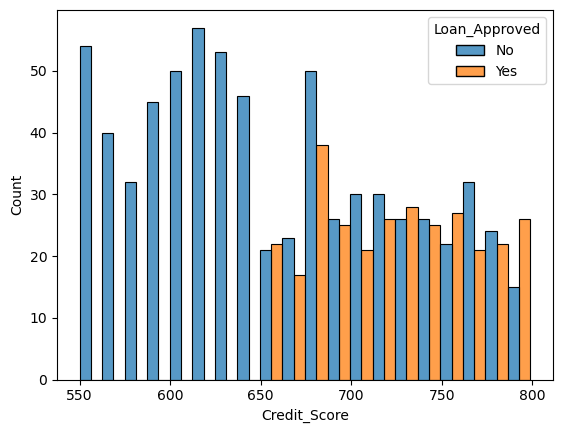

In [15]:
# credit score with loan approval

sns.histplot(
    data = df,
    x = "Credit_Score",
    hue= "Loan_Approved",
    bins = 20 ,
    multiple = "dodge"

)

<Axes: xlabel='Applicant_Income', ylabel='Count'>

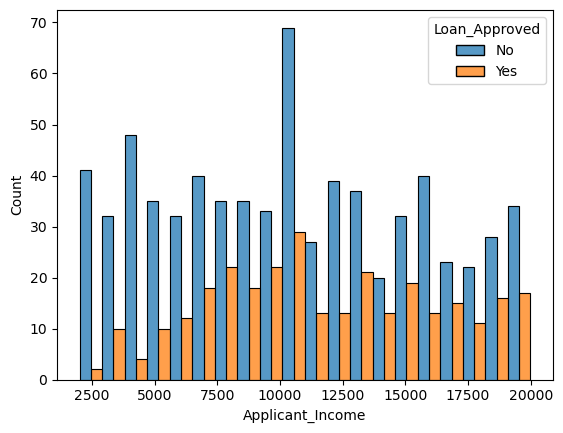

In [16]:
sns.histplot(
    data = df,
    x = "Applicant_Income",
    hue= "Loan_Approved",
    bins = 20 ,
    multiple = "dodge"

)

In [17]:
# Removing Applicant Id
df = df.drop("Applicant_ID", axis = 1)


In [18]:
df.head()

,Applicant_Income,Coapplicant_Income,Employment_Status,Age,Marital_Status,Dependents,Credit_Score,Existing_Loans,DTI_Ratio,Savings,Collateral_Value,Loan_Amount,Loan_Term,Loan_Purpose,Property_Area,Education_Level,Gender,Employer_Category,Loan_Approved
0,17795.0,1387.0,Salaried,51.0,Married,0.0,637.0,4.0,0.53,19403.0,45638.0,16619.0,84.0,Personal,Urban,Not Graduate,Female,Private,No
1,2860.0,2679.0,Salaried,46.0,Married,3.0,621.0,2.0,0.30,2580.0,49272.0,38687.0,48.0,Car,Semiurban,Graduate,Male,Private,No
2,7390.0,2106.0,Salaried,25.0,Single,2.0,674.0,4.0,0.20,13844.0,6908.0,27943.0,72.0,Business,Urban,Graduate,Female,Government,Yes
3,13964.0,8173.0,Salaried,40.0,Married,2.0,579.0,3.0,0.31,9553.0,10844.0,27819.0,60.0,Business,Rural,Graduate,Female,Government,No
4,13284.0,4223.0,Self-employed,31.0,Single,2.0,721.0,1.0,0.29,9386.0,37629.0,12741.0,72.0,Car,Urban,Graduate,Male,Private,Yes


 # ENCODING

In [19]:
df.head()
df.columns
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 19 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Applicant_Income    1000 non-null   float64
 1   Coapplicant_Income  1000 non-null   float64
 2   Employment_Status   1000 non-null   object 
 3   Age                 1000 non-null   float64
 4   Marital_Status      1000 non-null   object 
 5   Dependents          1000 non-null   float64
 6   Credit_Score        1000 non-null   float64
 7   Existing_Loans      1000 non-null   float64
 8   DTI_Ratio           1000 non-null   float64
 9   Savings             1000 non-null   float64
 10  Collateral_Value    1000 non-null   float64
 11  Loan_Amount         1000 non-null   float64
 12  Loan_Term           1000 non-null   float64
 13  Loan_Purpose        1000 non-null   object 
 14  Property_Area       1000 non-null   object 
 15  Education_Level     1000 non-null   object 
 16  Gender 

In [20]:
from sklearn.preprocessing import LabelEncoder, OneHotEncoder

le = LabelEncoder()
df["Education_Level"] = le.fit_transform(df["Education_Level"])
df["Loan_Approved"] = le.fit_transform(df["Loan_Approved"])

In [21]:
df.head()

,Applicant_Income,Coapplicant_Income,Employment_Status,Age,Marital_Status,Dependents,Credit_Score,Existing_Loans,DTI_Ratio,Savings,Collateral_Value,Loan_Amount,Loan_Term,Loan_Purpose,Property_Area,Education_Level,Gender,Employer_Category,Loan_Approved
0,17795.0,1387.0,Salaried,51.0,Married,0.0,637.0,4.0,0.53,19403.0,45638.0,16619.0,84.0,Personal,Urban,1,Female,Private,0
1,2860.0,2679.0,Salaried,46.0,Married,3.0,621.0,2.0,0.30,2580.0,49272.0,38687.0,48.0,Car,Semiurban,0,Male,Private,0
2,7390.0,2106.0,Salaried,25.0,Single,2.0,674.0,4.0,0.20,13844.0,6908.0,27943.0,72.0,Business,Urban,0,Female,Government,1
3,13964.0,8173.0,Salaried,40.0,Married,2.0,579.0,3.0,0.31,9553.0,10844.0,27819.0,60.0,Business,Rural,0,Female,Government,0
4,13284.0,4223.0,Self-employed,31.0,Single,2.0,721.0,1.0,0.29,9386.0,37629.0,12741.0,72.0,Car,Urban,0,Male,Private,1


In [22]:
cols = ["Employment_Status", "Marital_Status" ,"Loan_Purpose", "Property_Area","Gender","Employer_Category"]

ohe = OneHotEncoder(drop="first",sparse_output =False , handle_unknown ="ignore")
encoded = ohe.fit_transform(df[cols])
encoded_df = pd.DataFrame(encoded,columns = ohe.get_feature_names_out(cols), index = df.index)

df = pd.concat([df.drop(columns=cols),encoded_df], axis = 1)


In [23]:
df.head()
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 28 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   Applicant_Income                 1000 non-null   float64
 1   Coapplicant_Income               1000 non-null   float64
 2   Age                              1000 non-null   float64
 3   Dependents                       1000 non-null   float64
 4   Credit_Score                     1000 non-null   float64
 5   Existing_Loans                   1000 non-null   float64
 6   DTI_Ratio                        1000 non-null   float64
 7   Savings                          1000 non-null   float64
 8   Collateral_Value                 1000 non-null   float64
 9   Loan_Amount                      1000 non-null   float64
 10  Loan_Term                        1000 non-null   float64
 11  Education_Level                  1000 non-null   int64  
 12  Loan_Approved        

# COORELATION HEATMAPS

<Axes: >

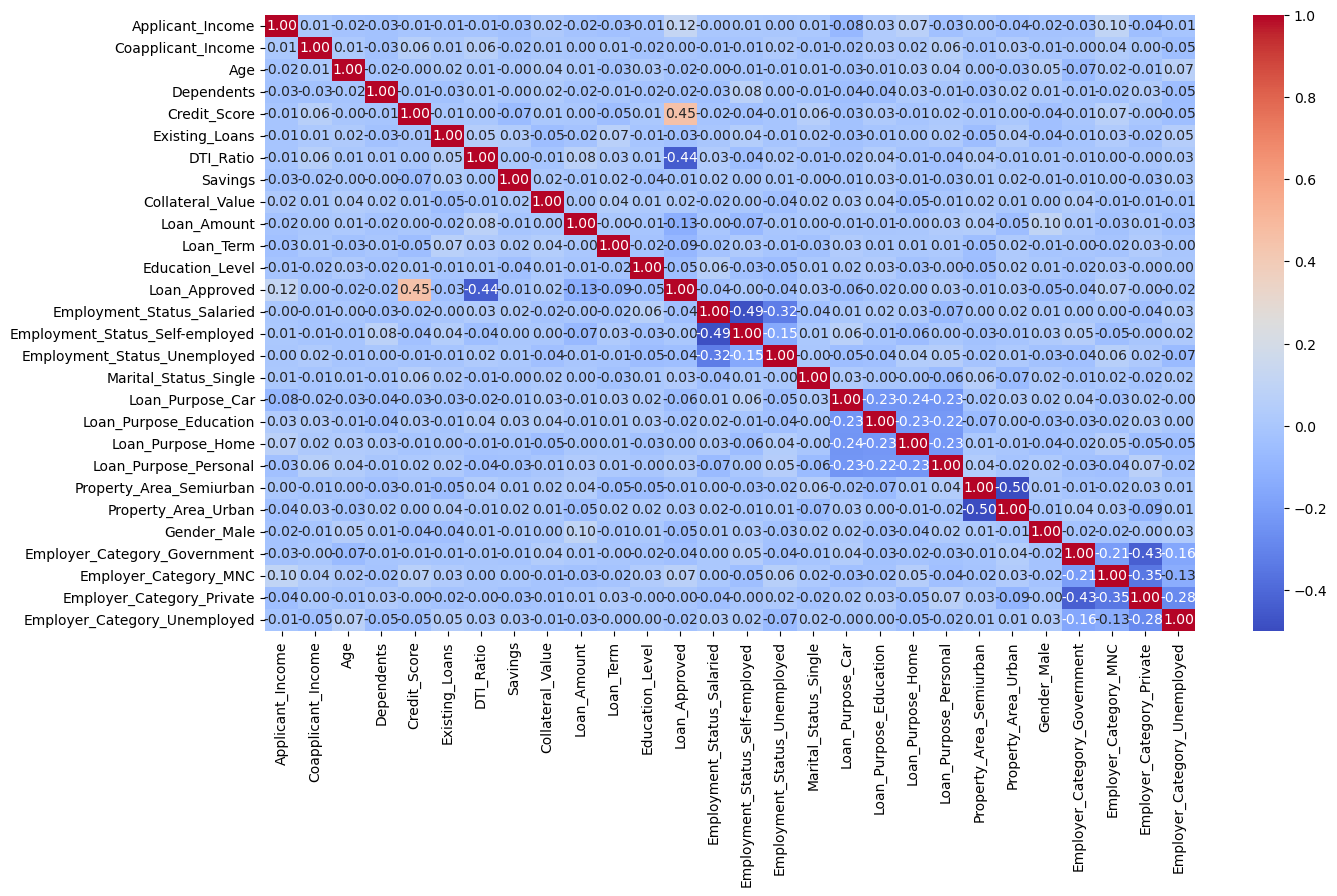

In [24]:
num_cols = df.select_dtypes(include="number")
corr_matrix = num_cols.corr()

plt.figure(figsize = (15, 8))
sns.heatmap(
    corr_matrix,
    annot = True,
    fmt = ".2f",
    cmap="coolwarm"
)

 num_cols.corr()["Loan_Approved"].sort_values(ascending=False)
     

# TRAIN TEST SPLIT AND FEATURE SCALING

In [25]:
X = df.drop("Loan_Approved", axis = 1)
y = df["Loan_Approved"]

In [26]:
y.head()

0    0
1    0
2    1
3    0
4    1
Name: Loan_Approved, dtype: int64

In [27]:
X_train, X_test, y_train, y_test  =  train_test_split(X,y, test_size = 0.2, random_state = 42)

In [28]:
X_test.head()

,Applicant_Income,Coapplicant_Income,Age,Dependents,Credit_Score,Existing_Loans,DTI_Ratio,Savings,Collateral_Value,Loan_Amount,...,Loan_Purpose_Education,Loan_Purpose_Home,Loan_Purpose_Personal,Property_Area_Semiurban,Property_Area_Urban,Gender_Male,Employer_Category_Government,Employer_Category_MNC,Employer_Category_Private,Employer_Category_Unemployed
521,13023.0,6675.0,53.000000,3.0,628.0,3.0,0.347263,10051.000000,26309.0,22947.000000,...,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0
737,15917.0,6787.0,42.000000,0.0,588.0,4.0,0.410000,922.000000,13476.0,20522.825263,...,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0
740,7560.0,3530.0,52.000000,3.0,606.0,0.0,0.580000,9940.452632,21795.0,5876.000000,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
660,19022.0,574.0,59.000000,0.0,725.0,4.0,0.410000,1463.000000,44498.0,8433.000000,...,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0
411,4967.0,5797.0,39.971579,3.0,697.0,4.0,0.580000,1095.000000,3017.0,33926.000000,...,0.0,1.0,0.0,0.0,1.0,1.0,1.0,0.0,0.0,0.0


In [29]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [30]:
X_train_scaled

array([[-1.01234556e+00,  1.02716377e+00, -8.22511453e-01, ...,
        -4.13887756e-01, -8.59726954e-01, -3.07231582e-01],
       [-1.23639141e+00, -1.59187898e+00,  9.15886794e-01, ...,
        -4.13887756e-01, -8.59726954e-01, -3.07231582e-01],
       [-1.15862490e-02,  1.33606578e+00, -3.65038230e-01, ...,
        -4.13887756e-01,  1.16316000e+00, -3.07231582e-01],
       ...,
       [-2.27277589e-01,  3.50089621e-01, -8.22511453e-01, ...,
        -4.13887756e-01,  1.16316000e+00, -3.07231582e-01],
       [ 1.12970221e+00, -4.64700438e-01,  1.19037073e+00, ...,
        -4.13887756e-01, -8.59726954e-01, -3.07231582e-01],
       [-1.75526629e+00,  1.43417276e-02,  9.40348249e-04, ...,
         2.41611400e+00, -8.59726954e-01, -3.07231582e-01]],
      shape=(800, 27))

# Train and Evaluate Models

In [31]:
#logictic regression
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score

log_model = LogisticRegression()
log_model.fit(X_train_scaled, y_train)

y_pred = log_model.predict(X_test_scaled)

#Evaluation of model
print("Logistic Regression Model")
print("Precision :", precision_score(y_test,y_pred))
print("Recall :", recall_score(y_test,y_pred))
print("Accuracy :", accuracy_score(y_test,y_pred))
print(" F1_score :", f1_score(y_test,y_pred))
print("CM :", confusion_matrix(y_test,y_pred))

Logistic Regression Model
Precision : 0.7833333333333333
Recall : 0.7704918032786885
Accuracy : 0.865
 F1_score : 0.7768595041322314
CM : [[126  13]
 [ 14  47]]


In [32]:
#KNN 

from sklearn.neighbors import KNeighborsClassifier

knn_model = KNeighborsClassifier(n_neighbors=5)
knn_model.fit(X_train_scaled, y_train)

y_pred = knn_model.predict(X_test_scaled)

#Evaluation of model
print("KNN Model")
print("Precision :", precision_score(y_test,y_pred))
print("Recall :", recall_score(y_test,y_pred))
print("Accuracy :", accuracy_score(y_test,y_pred))
print(" F1_score :", f1_score(y_test,y_pred))
print("CM :", confusion_matrix(y_test,y_pred))

KNN Model
Precision : 0.6274509803921569
Recall : 0.5245901639344263
Accuracy : 0.76
 F1_score : 0.5714285714285714
CM : [[120  19]
 [ 29  32]]


In [33]:
#Naive bayes

from sklearn.naive_bayes import GaussianNB
nb_model = GaussianNB()
nb_model.fit(X_train_scaled, y_train)

y_pred = nb_model.predict(X_test_scaled)

#Evaluation of model
print("Naive Bayes Model")
print("Precision :", precision_score(y_test,y_pred))
print("Recall :", recall_score(y_test,y_pred))
print("Accuracy :", accuracy_score(y_test,y_pred))
print(" F1_score :", f1_score(y_test,y_pred))
print("CM :", confusion_matrix(y_test,y_pred))

Naive Bayes Model
Precision : 0.8035714285714286
Recall : 0.7377049180327869
Accuracy : 0.865
 F1_score : 0.7692307692307693
CM : [[128  11]
 [ 16  45]]


# Best model on the basics of precision => NaiveBayes

# Feature engineering

In [34]:
#Add or transform features

df["DTI_Ratio_sq"] = df["DTI_Ratio"] ** 2
df["Credit_Score_sq"] = df["Credit_Score"] ** 2

# df["Applicant_Income_log"] = np.log1p(df["Applicant_Income"])

X = df.drop(columns = ["Loan_Approved","DTI_Ratio","Credit_Score"])
y  = df["Loan_Approved"]

#train_test_split

X_train, X_test, y_train, y_test  =  train_test_split(X,y, test_size = 0.2, random_state = 42)

#scaler
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [35]:
X_train.head()

,Applicant_Income,Coapplicant_Income,Age,Dependents,Existing_Loans,Savings,Collateral_Value,Loan_Amount,Loan_Term,Education_Level,...,Loan_Purpose_Personal,Property_Area_Semiurban,Property_Area_Urban,Gender_Male,Employer_Category_Government,Employer_Category_MNC,Employer_Category_Private,Employer_Category_Unemployed,DTI_Ratio_sq,Credit_Score_sq
29,5890.000000,8041.0,31.000000,0.0,0.000000,11906.0,8150.000000,29287.000000,12.0,1,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0121,363609.000000
535,4779.000000,529.0,50.000000,0.0,0.000000,5369.0,5430.000000,14786.000000,72.0,1,...,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0441,376996.000000
695,10852.571579,8927.0,36.000000,0.0,4.000000,3186.0,24802.792632,20522.825263,48.0,1,...,1.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0484,341056.000000
557,2384.000000,2113.0,39.971579,1.0,4.000000,11882.0,48542.000000,13312.000000,24.0,0,...,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.1156,527076.000000
836,5228.000000,5249.0,42.000000,1.0,1.950526,17669.0,24802.792632,13906.000000,84.0,0,...,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0324,457021.542187


In [36]:
#logictic regression
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score

log_model = LogisticRegression()
log_model.fit(X_train_scaled, y_train)

y_pred = log_model.predict(X_test_scaled)

#Evaluation of model
print("Logistic Regression Model")
print("Precision :", precision_score(y_test,y_pred))
print("Recall :", recall_score(y_test,y_pred))
print("Accuracy :", accuracy_score(y_test,y_pred))
print(" F1_score :", f1_score(y_test,y_pred))
print("CM :", confusion_matrix(y_test,y_pred))

Logistic Regression Model
Precision : 0.7903225806451613
Recall : 0.8032786885245902
Accuracy : 0.875
 F1_score : 0.7967479674796748
CM : [[126  13]
 [ 12  49]]


In [37]:
#KNN 

from sklearn.neighbors import KNeighborsClassifier

knn_model = KNeighborsClassifier(n_neighbors=5)
knn_model.fit(X_train_scaled, y_train)

y_pred = knn_model.predict(X_test_scaled)

#Evaluation of model
print("KNN Model")
print("Precision :", precision_score(y_test,y_pred))
print("Recall :", recall_score(y_test,y_pred))
print("Accuracy :", accuracy_score(y_test,y_pred))
print(" F1_score :", f1_score(y_test,y_pred))
print("CM :", confusion_matrix(y_test,y_pred))

KNN Model
Precision : 0.62
Recall : 0.5081967213114754
Accuracy : 0.755
 F1_score : 0.5585585585585585
CM : [[120  19]
 [ 30  31]]


In [39]:
#Naive bayes

from sklearn.naive_bayes import GaussianNB
nb_model = GaussianNB()
nb_model.fit(X_train_scaled, y_train)

y_pred = nb_model.predict(X_test_scaled)

#Evaluation of model
print("Naive Bayes Model")
print("Precision :", precision_score(y_test,y_pred))
print("Recall :", recall_score(y_test,y_pred))
print("Accuracy :", accuracy_score(y_test,y_pred))
print("F1_score :", f1_score(y_test,y_pred))
print("CM :", confusion_matrix(y_test,y_pred))

Naive Bayes Model
Precision : 0.7833333333333333
Recall : 0.7704918032786885
Accuracy : 0.865
F1_score : 0.7768595041322314
CM : [[126  13]
 [ 14  47]]


# Decision Tree Classifier

In [40]:
from sklearn.tree import DecisionTreeClassifier

dmodel = DecisionTreeClassifier()
dmodel.fit(X_train, y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [43]:
y_pred = dmodel.predict(X_test)
print("Accuracy score:", accuracy_score(y_test, y_pred))

Accuracy score: 0.895


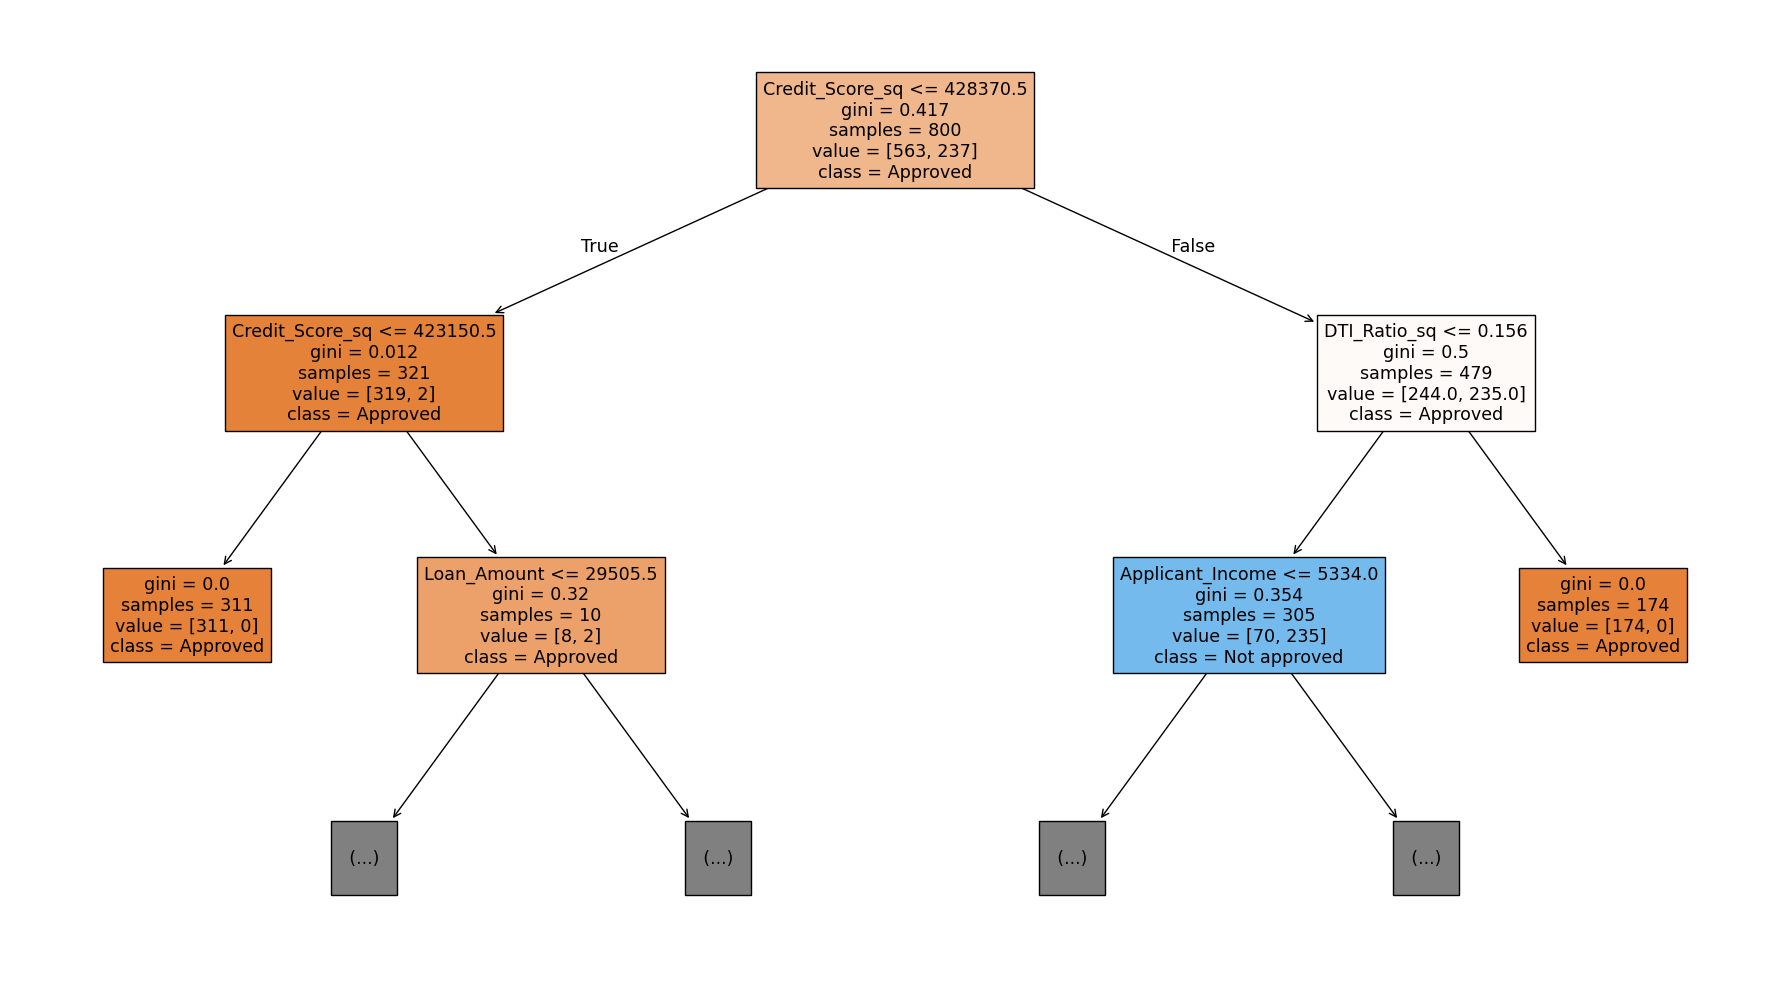

In [46]:
from sklearn.tree import plot_tree

plt.figure(figsize=(18, 10))

plot_tree(
    dmodel,
    feature_names =X.columns,
    class_names = ["Approved", "Not approved"],
    filled=True,
    max_depth=2
)

plt.tight_layout()
plt.show()

# Decision Tree with Pre-pruning

For Depth 2, accuracy = 0.885
For Depth 3, accuracy = 0.89
For Depth 4, accuracy = 0.91
For Depth 5, accuracy = 0.915


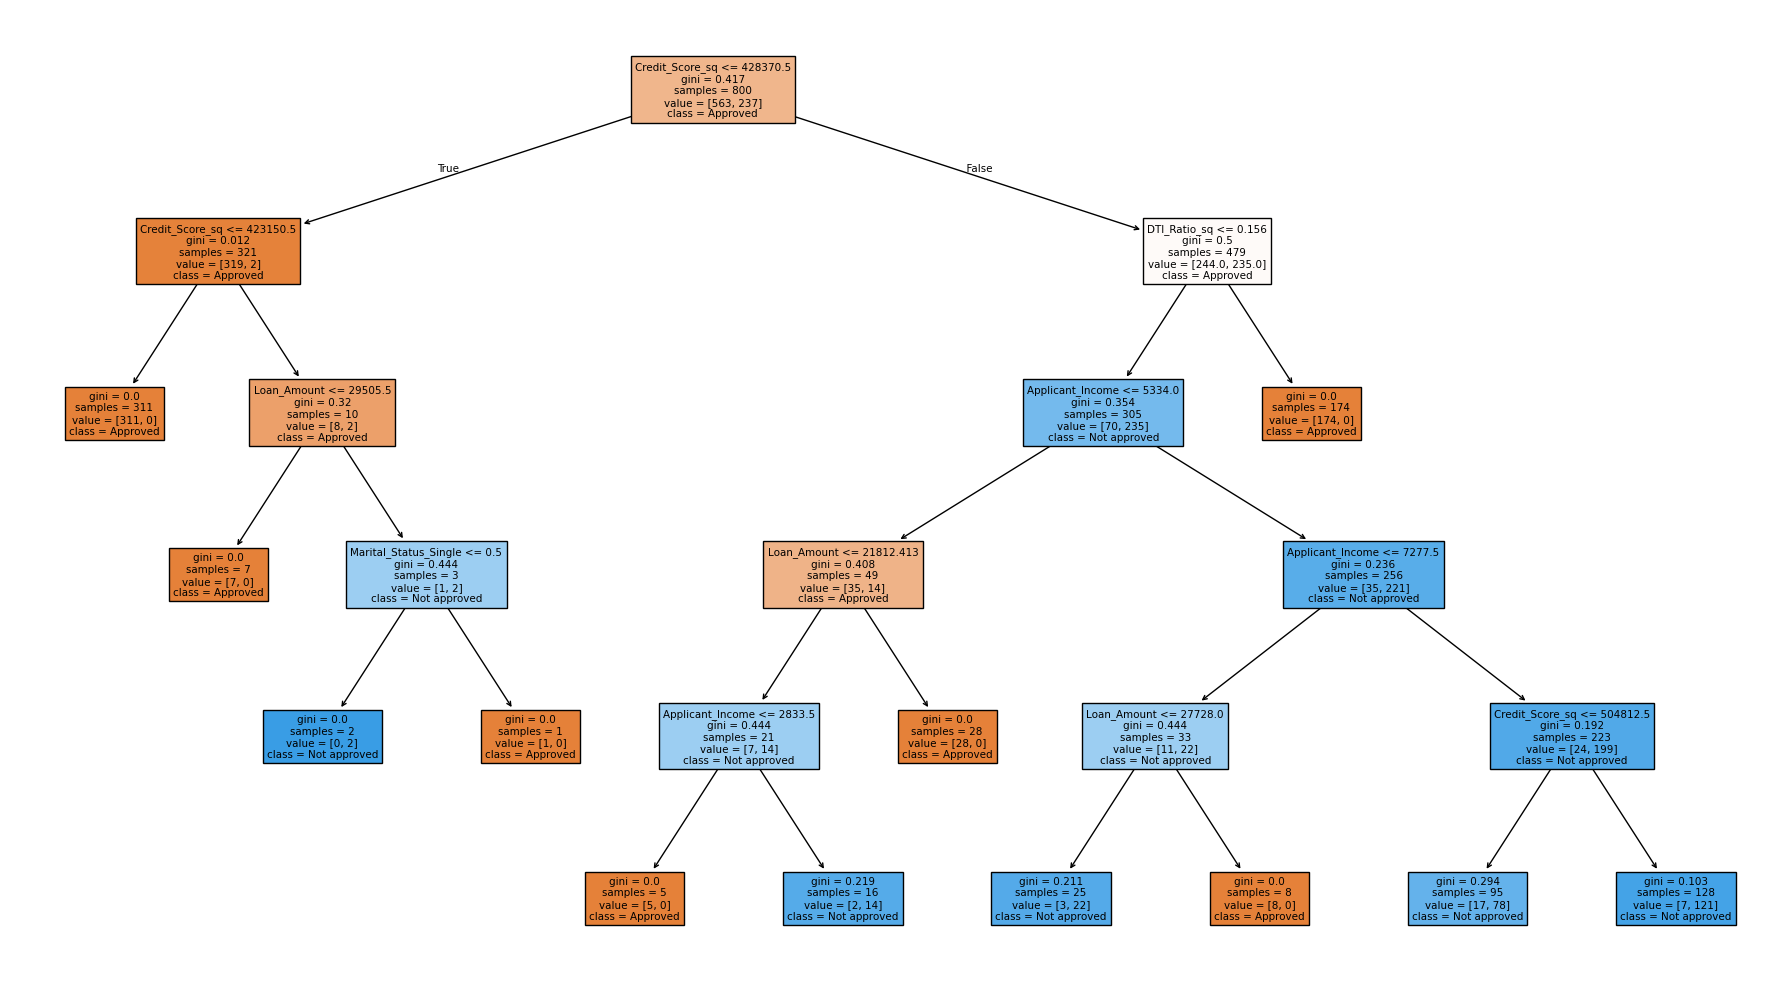

For Depth 6, accuracy = 0.91
For Depth 7, accuracy = 0.91
For Depth 8, accuracy = 0.91
For Depth 9, accuracy = 0.915
For Depth 10, accuracy = 0.9


In [54]:
max_depths = [2, 3, 4, 5, 6, 7, 8, 9, 10]

for depth in max_depths:
    model = DecisionTreeClassifier(max_depth = depth)
    model.fit(X_train, y_train)

    acc = model.score(X_test, y_test)

    print(f"For Depth {depth}, accuracy = {acc}")

    if depth == 5:
        plt.figure(figsize=(18, 10))

        plot_tree(
            model,
            feature_names =X.columns,
            class_names = ["Approved", "Not approved"],
            filled=True
        )
        
        plt.tight_layout()
        plt.show()

For sample split 5, accuracy = 0.91


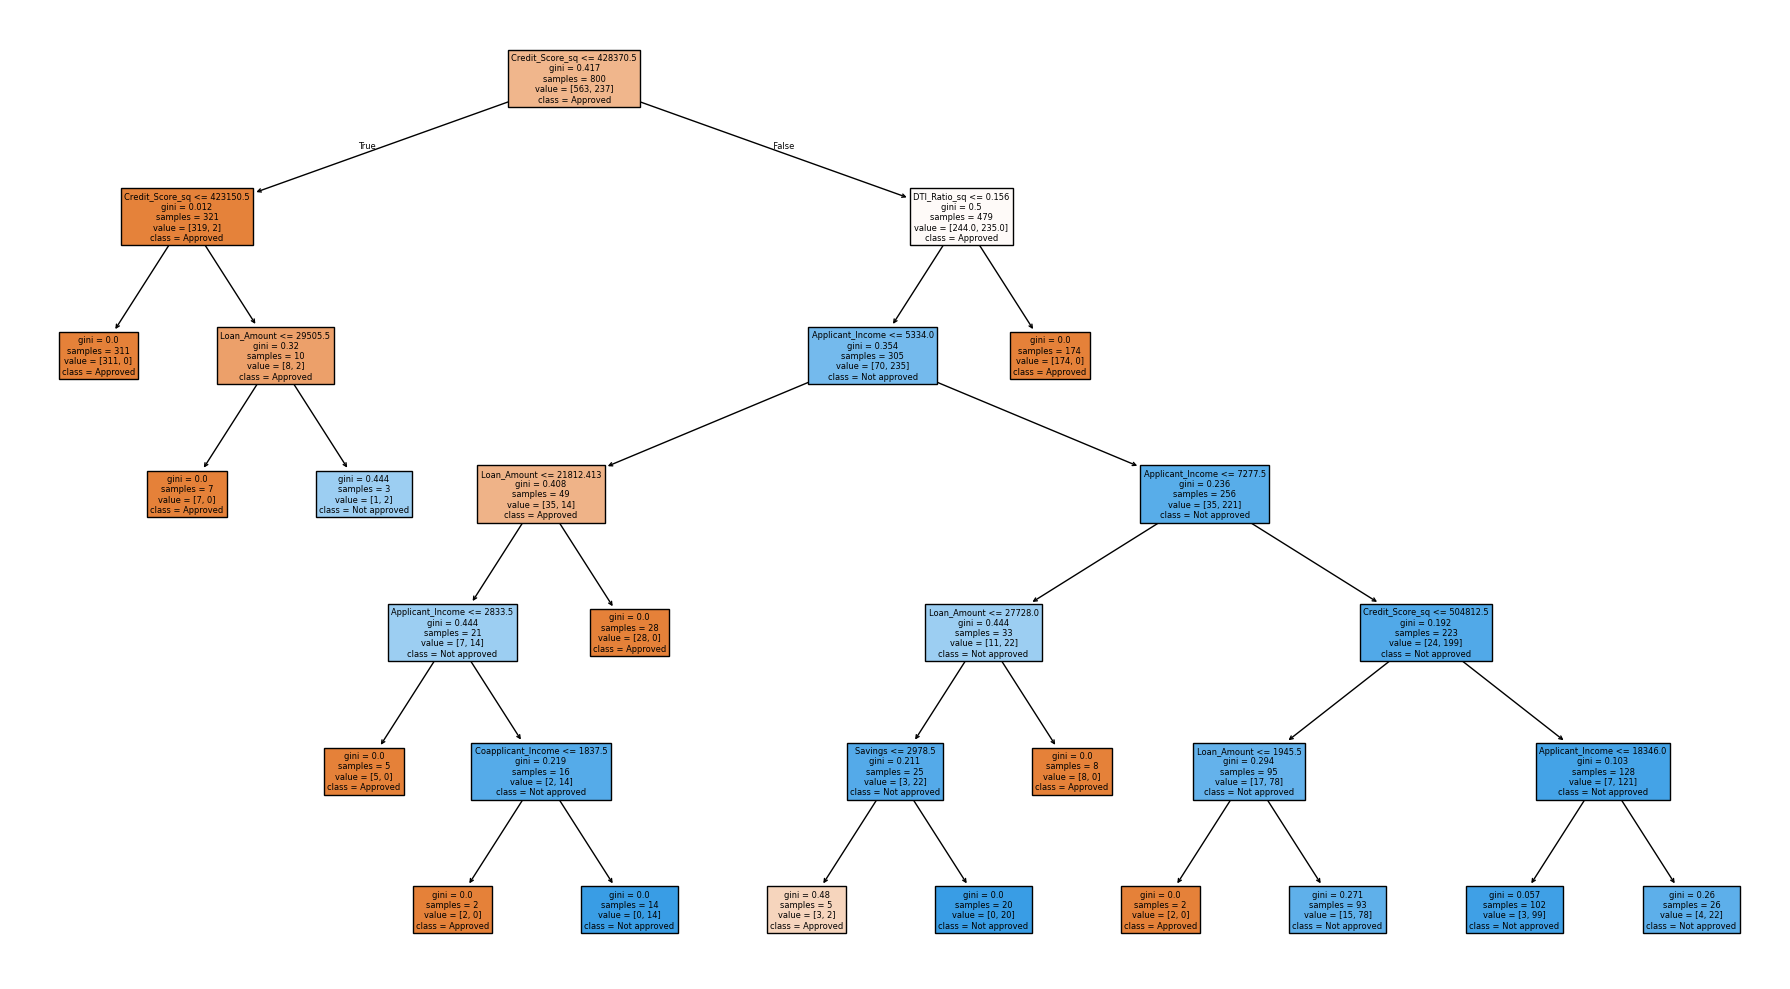

For sample split 10, accuracy = 0.91
For sample split 15, accuracy = 0.91
For sample split 20, accuracy = 0.905
For sample split 25, accuracy = 0.905
For sample split 30, accuracy = 0.91


In [55]:
min_samples_splits = [5, 10, 15, 20, 25, 30]

for split in min_samples_splits:
    model = DecisionTreeClassifier(max_depth = 6, min_samples_split=split)
    model.fit(X_train, y_train)

    acc = model.score(X_test, y_test)

    print(f"For sample split {split}, accuracy = {acc}")

    if split == 5:
        plt.figure(figsize=(18, 10))

        plot_tree(
            model,
            feature_names =X.columns,
            class_names = ["Approved", "Not approved"],
            filled=True
        )
        
        plt.tight_layout()
        plt.show()

# Decision Tree with Post Pruning

In [56]:
full_tree = DecisionTreeClassifier(random_state=42)
full_tree.fit(X_train, y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [57]:
path = full_tree.cost_complexity_pruning_path(X_train, y_train)
ccp_alphas = path.ccp_alphas

print(ccp_alphas)

[0.         0.0011875  0.00123611 0.0016024  0.00165628 0.00166667
 0.00166667 0.00183943 0.0022549  0.00229619 0.00270846 0.00277401
 0.003      0.0036     0.004375   0.00729167 0.00769725 0.01333333
 0.03429896 0.13858348]


In [60]:
# train our model for all alphas 

trees = []

for alpha in ccp_alphas:
    model = DecisionTreeClassifier(random_state=42, ccp_alpha=alpha)
    model.fit(X_train, y_train)
    acc = model.score(X_test, y_test)

    trees.append((model, alpha))

best_acc = 0 
best_alpha= 0 

for model, alpha in trees:
    curr_acc = model.score(X_test, y_test)
    if curr_acc > best_acc:
        best_acc = curr_acc
        best_alpha = alpha

print("Best Alpha:", best_alpha)
print("Best Accuracy:", best_acc)

Best Alpha: 0.002774009621817588
Best Accuracy: 0.92


In [64]:
best_model = DecisionTreeClassifier(ccp_alpha = best_alpha)
best_model.fit(X_train, y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [65]:
y_pred = best_model.predict(X_test)

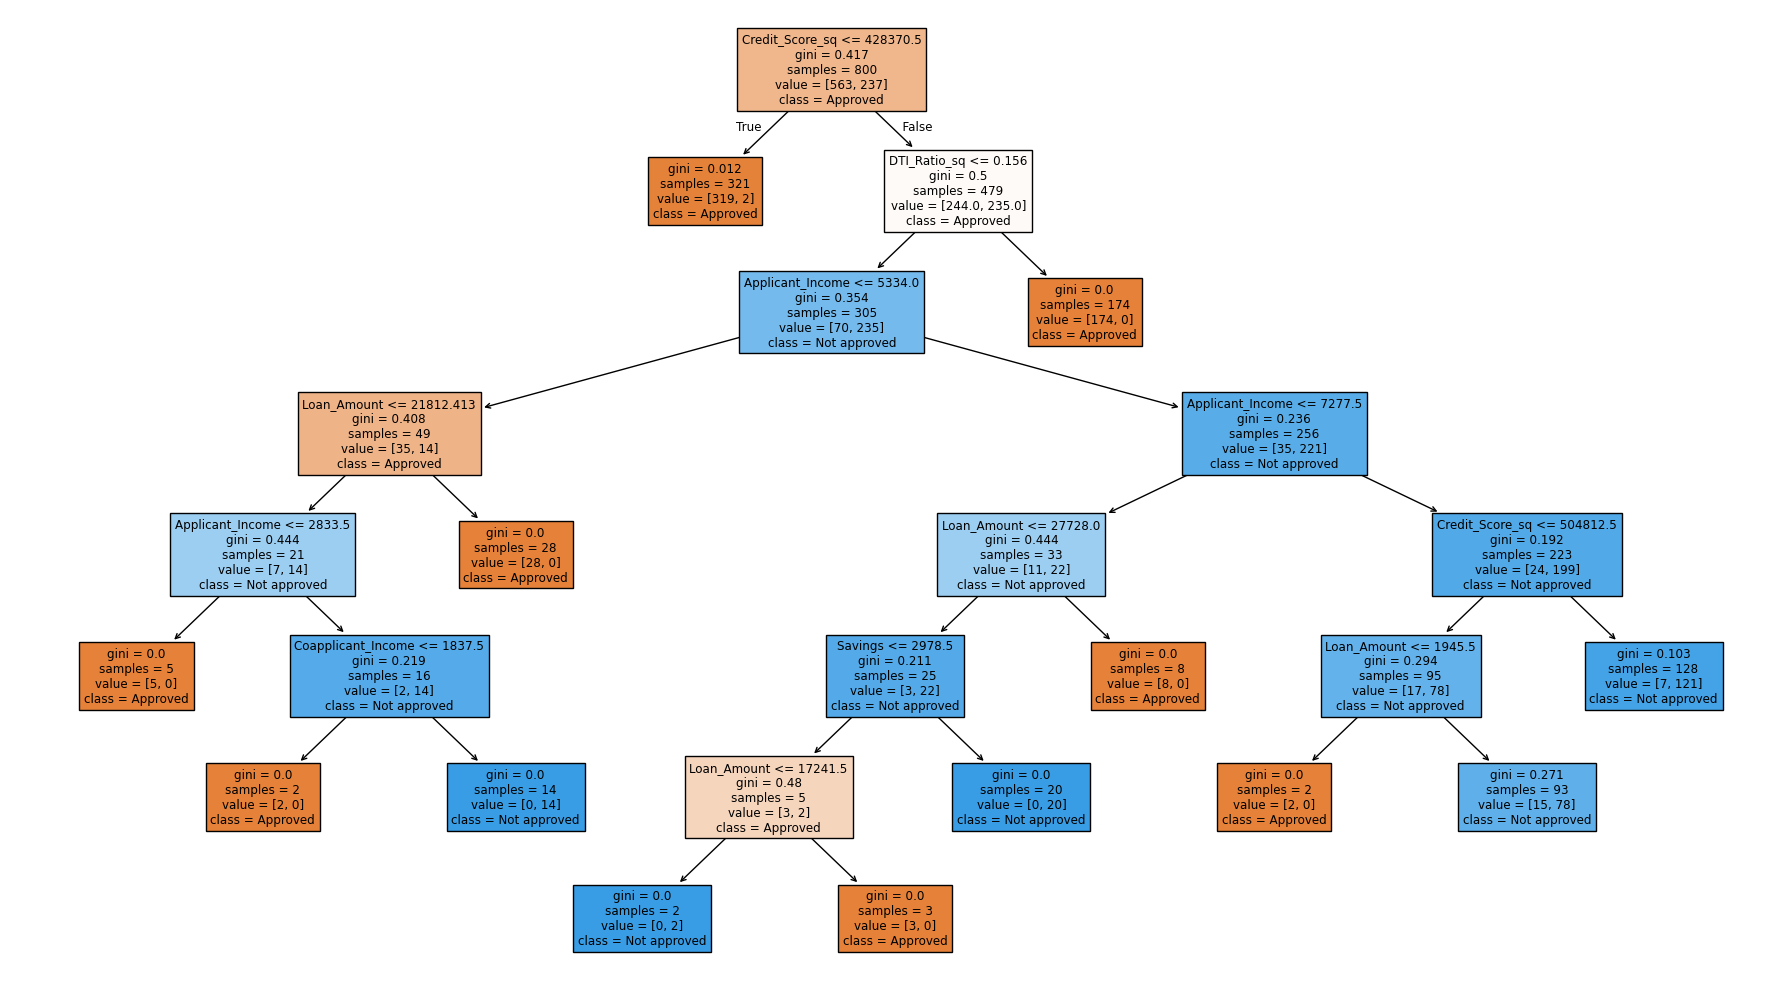

In [66]:
plt.figure(figsize=(18, 10))

plot_tree(
    best_model,
    feature_names =X.columns,
    class_names = ["Approved", "Not approved"],
    filled=True
)

plt.tight_layout()
plt.show()

In [67]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("Best Alpha:", best_alpha)
print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("F1 Score:", f1)

Best Alpha: 0.002774009621817588
Accuracy: 0.915
Precision: 0.8333333333333334
Recall: 0.9016393442622951
F1 Score: 0.8661417322834646
